# ResNet SimCLRv2 
Load đúng `SimCLRFineTuner`, không strip `backbone.`. In val acc + plots.

In [2]:
from pathlib import Path
import sys, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
PROJECT_DIR = Path(r"D:\ML3")
DATA_ROOT = PROJECT_DIR / "data"
CKPT_DIR = PROJECT_DIR / "checkpoints_finetune_2"
LOG_DIR = PROJECT_DIR / "logs"
OUT_DIR = PROJECT_DIR / "eval_results"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0

assert PROJECT_DIR.exists(), PROJECT_DIR
assert DATA_ROOT.exists(), DATA_ROOT
assert CKPT_DIR.exists(), CKPT_DIR

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_ROOT:", DATA_ROOT)
print("CKPT_DIR:", CKPT_DIR)
print("DEVICE:", DEVICE)


PROJECT_DIR: D:\ML3
DATA_ROOT: D:\ML3\data
CKPT_DIR: D:\ML3\checkpoints_finetune_2
DEVICE: cuda


In [4]:
sys.path.insert(0, str(PROJECT_DIR))

from resnet18 import build_resnet
from ssl_simclr import ProjectionHead, SimCLRFineTuner
from dataset import get_dataloaders

print("imports OK")


imports OK


In [5]:
def latest_ckpt(folder):
    pts = sorted(Path(folder).rglob("*.pt"), key=lambda p: p.stat().st_mtime)
    best = [p for p in pts if "best" in p.name.lower()]
    return best[-1] if best else pts[-1]

CKPT = latest_ckpt(CKPT_DIR)
ckpt = torch.load(CKPT, map_location="cpu")

print("CKPT:", CKPT)
print("keys:", list(ckpt.keys()))
print("epoch:", ckpt.get("epoch"))
print("best_acc:", ckpt.get("best_acc"))
print("mode:", ckpt.get("mode"))
print("args:", ckpt.get("args"))


CKPT: D:\ML3\checkpoints_finetune_2\finetune_resnet50_best.pt
keys: ['epoch', 'model', 'optimizer', 'scheduler', 'args', 'best_acc', 'mode']
epoch: 115
best_acc: 83.8875
mode: finetune
args: {'mode': 'finetune', 'arch': 'resnet50', 'num_classes': 10, 'data_root': './data', 'dataset': 'stl10', 'labeled_data_root': '', 'labeled_dataset': 'stl10', 'download': False, 'image_size': 96, 'epochs': 120, 'batch_size': 64, 'lr': 0.01, 'min_lr': 0.0, 'momentum': 0.9, 'weight_decay': 0.0, 'optimizer': 'sgd', 'warmup_epochs': 0, 'num_workers': 2, 'no_amp': False, 'log_every': 20, 'proj_dim': 128, 'proj_hidden_dim': 0, 'proj_layers': 3, 'finetune_proj_layers': 1, 'temperature': 0.2, 'out_dir': './checkpoints_finetune_2', 'save_every': 10, 'resume': '', 'ckpt': './checkpoints_finetune_2/finetune_resnet50_epoch_050.pt', 'distributed': False, 'master_port': 29500, 'rank': 0, 'world_size': 1, 'local_rank': 0, 'is_main': True}


C:\Users\DELL\AppData\Local\Temp\ipykernel_25824\609598939.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT, map_location="cpu")


In [6]:
args = ckpt["args"]
state = ckpt["model"]

# CHỈ bỏ prefix module. nếu có DDP/DataParallel.
# KHÔNG bỏ "backbone." vì checkpoint fine-tune cần key backbone.xxx.
state = {k.replace("module.", "", 1): v for k, v in state.items()}

print("state sample:")
for k in list(state.keys())[:20]:
    print(" ", k)


state sample:
  backbone.conv1.weight
  backbone.bn1.weight
  backbone.bn1.bias
  backbone.bn1.running_mean
  backbone.bn1.running_var
  backbone.bn1.num_batches_tracked
  backbone.layer1.0.conv1.weight
  backbone.layer1.0.bn1.weight
  backbone.layer1.0.bn1.bias
  backbone.layer1.0.bn1.running_mean
  backbone.layer1.0.bn1.running_var
  backbone.layer1.0.bn1.num_batches_tracked
  backbone.layer1.0.conv2.weight
  backbone.layer1.0.bn2.weight
  backbone.layer1.0.bn2.bias
  backbone.layer1.0.bn2.running_mean
  backbone.layer1.0.bn2.running_var
  backbone.layer1.0.bn2.num_batches_tracked
  backbone.layer1.0.conv3.weight
  backbone.layer1.0.bn3.weight


In [7]:
arch = args.get("arch", "resnet50")
num_classes = int(args.get("num_classes", 10))
image_size = int(args.get("image_size", 96))
batch_size = int(args.get("batch_size", 128))
proj_dim = int(args.get("proj_dim", 128))
proj_layers = int(args.get("proj_layers", 3))
ft_proj_layers = int(args.get("finetune_proj_layers", 1))

backbone = build_resnet(arch, num_classes=num_classes)
backbone.fc = nn.Identity()
feat_dim = getattr(backbone, "feature_dim", 512)
hidden_dim = int(args.get("proj_hidden_dim", 0) or feat_dim)

projector = ProjectionHead(
    in_dim=feat_dim,
    proj_dim=proj_dim,
    hidden_dim=hidden_dim,
    num_layers=proj_layers,
)

model = SimCLRFineTuner(
    backbone=backbone,
    projector=projector,
    num_classes=num_classes,
    include_proj_layers=ft_proj_layers,
)

msg = model.load_state_dict(state, strict=True)
print("LOAD STRICT OK:", msg)

model = model.to(DEVICE).eval()
print("params M:", round(sum(p.numel() for p in model.parameters()) / 1e6, 2))


LOAD STRICT OK: <All keys matched successfully>
params M: 27.73


In [8]:
_, val_loader = get_dataloaders(
    batch_size=batch_size,
    data_root=str(DATA_ROOT),
    dataset=args.get("labeled_dataset", "stl10"),
    image_size=image_size,
    num_workers=NUM_WORKERS,
    download=False,
    use_cuda=(DEVICE.type == "cuda"),
    distributed=False,
)

class_names = getattr(val_loader.dataset, "classes", [str(i) for i in range(num_classes)])
print("val samples:", len(val_loader.dataset))
print("classes:", class_names)


val samples: 8000
classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [9]:
@torch.no_grad()
def evaluate(model, loader, device):
    ce = nn.CrossEntropyLoss(reduction="sum")
    total_loss = 0.0
    correct = 0
    total = 0
    y_true, y_pred, y_prob = [], [], []
    t0 = time.time()

    model.eval()
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = ce(logits, y)
        pred = logits.argmax(1)

        total_loss += loss.item()
        correct += (pred == y).sum().item()
        total += y.numel()

        y_true.append(y.cpu())
        y_pred.append(pred.cpu())
        y_prob.append(torch.softmax(logits, 1).cpu())

    return {
        "loss": total_loss / total,
        "acc": correct / total,
        "correct": correct,
        "total": total,
        "sec": time.time() - t0,
        "y_true": torch.cat(y_true).numpy(),
        "y_pred": torch.cat(y_pred).numpy(),
        "y_prob": torch.cat(y_prob).numpy(),
    }

res = evaluate(model, val_loader, DEVICE)

print("VAL_LOSS:", round(res["loss"], 4))
print("VAL_ACC :", f'{res["acc"]*100:.2f}%')
print("CORRECT :", f'{res["correct"]}/{res["total"]}')
print("TIME    :", f'{res["sec"]:.1f}s')


VAL_LOSS: 0.7327
VAL_ACC : 83.89%
CORRECT : 6711/8000
TIME    : 5.7s


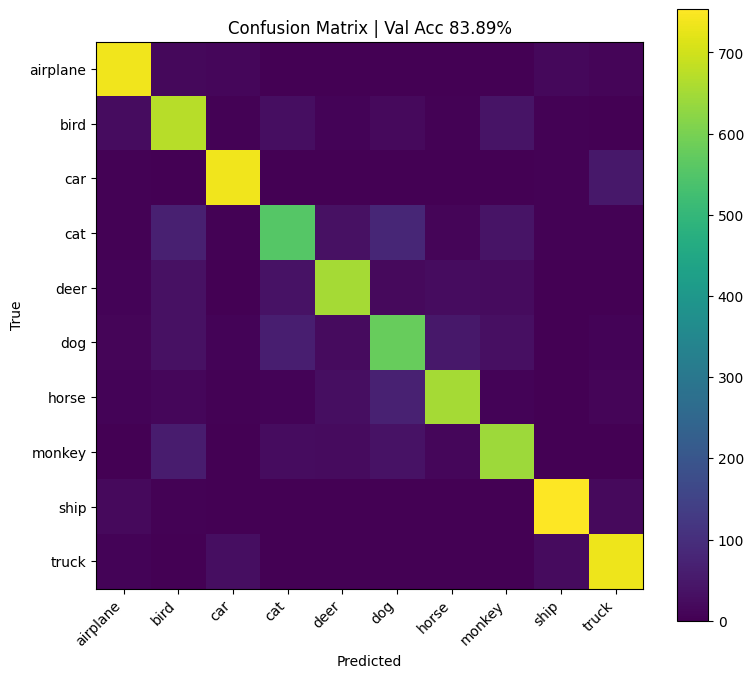

In [10]:
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(res["y_true"], res["y_pred"]):
    cm[int(t), int(p)] += 1

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Confusion Matrix | Val Acc {res['acc']*100:.2f}%")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


,class,correct,total,acc
8,ship,753,800,0.94125
2,car,738,800,0.92250
0,airplane,737,800,0.92125
9,truck,734,800,0.91750
1,bird,671,800,0.83875
6,horse,652,800,0.81500
4,deer,651,800,0.81375
7,monkey,643,800,0.80375
5,dog,578,800,0.72250
3,cat,554,800,0.69250


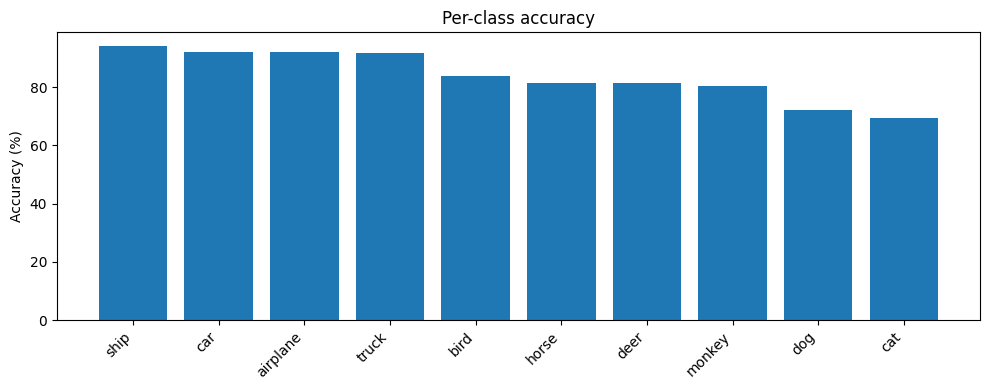

In [11]:
per_total = cm.sum(axis=1)
per_correct = np.diag(cm)
per_acc = per_correct / np.maximum(per_total, 1)

df_class = pd.DataFrame({
    "class": class_names,
    "correct": per_correct,
    "total": per_total,
    "acc": per_acc,
}).sort_values("acc", ascending=False)

display(df_class)

plt.figure(figsize=(10, 4))
plt.bar(df_class["class"], df_class["acc"] * 100)
plt.ylabel("Accuracy (%)")
plt.title("Per-class accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [12]:
def parse_logs(log_dir):
    rows = []
    pre_re = re.compile(r"Epoch\s+(\d+)/(\d+)\s+\|\s+pretrain_loss=([0-9.]+).*?time=([0-9.]+)s")
    ft_re = re.compile(r"Epoch\s+(\d+)/(\d+)\s+\|\s+train_loss=([0-9.]+)\s+train_acc=([0-9.]+)%\s+\|\s+val_loss=([0-9.]+)\s+val_acc=([0-9.]+)%.*?time=([0-9.]+)s")

    for p in sorted(Path(log_dir).glob("*.log")):
        for line in p.read_text(errors="ignore").splitlines():
            m = pre_re.search(line)
            if m:
                rows.append({
                    "log": p.name, "mode": "pretrain",
                    "epoch": int(m.group(1)), "max_epoch": int(m.group(2)),
                    "train_loss": float(m.group(3)), "train_acc": np.nan,
                    "val_loss": np.nan, "val_acc": np.nan,
                    "time_sec": float(m.group(4)),
                })
            m = ft_re.search(line)
            if m:
                rows.append({
                    "log": p.name, "mode": "finetune",
                    "epoch": int(m.group(1)), "max_epoch": int(m.group(2)),
                    "train_loss": float(m.group(3)), "train_acc": float(m.group(4)),
                    "val_loss": float(m.group(5)), "val_acc": float(m.group(6)),
                    "time_sec": float(m.group(7)),
                })
    return pd.DataFrame(rows)

df_log = parse_logs(LOG_DIR)
print("parsed rows:", len(df_log))
display(df_log.tail(20))


parsed rows: 0


""


In [13]:
if len(df_log):
    pre = df_log[df_log["mode"] == "pretrain"]
    ft = df_log[df_log["mode"] == "finetune"]

    if len(pre):
        plt.figure(figsize=(8,4))
        plt.plot(pre["epoch"], pre["train_loss"])
        plt.title("Pretrain loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    if len(ft):
        plt.figure(figsize=(8,4))
        plt.plot(ft["epoch"], ft["train_loss"], label="train_loss")
        plt.plot(ft["epoch"], ft["val_loss"], label="val_loss")
        plt.title("Fine-tune loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8,4))
        plt.plot(ft["epoch"], ft["train_acc"], label="train_acc")
        plt.plot(ft["epoch"], ft["val_acc"], label="val_acc")
        plt.title("Fine-tune accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        best = ft.loc[ft["val_acc"].idxmax()]
        print("BEST LOG VAL_ACC:", f'{best["val_acc"]:.2f}%', "epoch:", int(best["epoch"]))


In [14]:
OUT_DIR.mkdir(exist_ok=True)

summary = pd.DataFrame([{
    "checkpoint": str(CKPT),
    "best_acc_in_ckpt": ckpt.get("best_acc"),
    "eval_val_loss": res["loss"],
    "eval_val_acc": res["acc"] * 100,
    "correct": res["correct"],
    "total": res["total"],
}])

summary.to_csv(OUT_DIR / "fixed_eval_summary.csv", index=False)
df_class.to_csv(OUT_DIR / "fixed_eval_per_class.csv", index=False)
df_log.to_csv(OUT_DIR / "fixed_eval_parsed_logs.csv", index=False)

display(summary)
print("saved:", OUT_DIR)


,checkpoint,best_acc_in_ckpt,eval_val_loss,eval_val_acc,correct,total
0,D:\ML3\checkpoints_finetune_2\finetune_resnet5...,83.8875,0.732678,83.8875,6711,8000


saved: D:\ML3\eval_results
